# Pong Training Workflow (NEST R-STDP / dopaminergic)

End-to-end NeuroWorkflow built from the participant's `pong_simulation` and `generate_gif` notebooks.

**Graph**

```
NESTKernelNode --kernel_ready--> LeftPlayer  (NESTPongPlayerNode)
               \-kernel_ready--> RightPlayer (NESTPongPlayerNode)
LeftPlayer.player_network  --> MatchSimulation (PongMatchSimulationNode)
RightPlayer.player_network --> MatchSimulation
MatchSimulation.{game_trace,left_performance,right_performance} --> RenderGif (PongGifRendererNode)
```

Run this notebook with the **`neuroworkflow-hackathon` conda env** kernel (it has `nest`, `neuroworkflow`, `imageio`).

In [1]:
import os
import sys

from neuroworkflow import WorkflowBuilder

# Make node modules + helper modules (pong.py, networks.py) importable.
try:
    _HERE = os.path.dirname(os.path.abspath(__file__))
except NameError:
    _HERE = os.getcwd()  # Jupyter: CWD is the my_nodes/ folder
if _HERE not in sys.path:
    sys.path.insert(0, _HERE)

from NESTKernelNode import NESTKernelNode
from NESTPongPlayerNode import NESTPongPlayerNode
from PongMatchSimulationNode import PongMatchSimulationNode
from PongGifRendererNode import PongGifRendererNode


              -- N E S T --
  Copyright (C) 2004 The NEST Initiative

 Version: 3.9.0
 Built: Apr 14 2026 11:46:17

 This program is provided AS IS and comes with
 NO WARRANTY. See the file LICENSE for details.

 Problems or suggestions?
   Visit https://www.nest-simulator.org

 Type 'nest.help()' to find out more about NEST.



## 1. Instantiate and configure nodes

Defaults match the original script: clean R-STDP (left) vs noisy R-STDP (right), 20 neurons, 50 game iterations.
To showcase dopaminergic plasticity instead, set one player to `learning_rule="dopa"` (at most **one** `dopa` player per kernel).

In [8]:
kernel = NESTKernelNode("Kernel")
left_player = NESTPongPlayerNode("LeftPlayer")
right_player = NESTPongPlayerNode("RightPlayer")
simulation = PongMatchSimulationNode("MatchSimulation")
renderer = PongGifRendererNode("RenderGif")

kernel.configure(random_seed=1, resolution_ms=0.1, reset_kernel=True)
left_player.configure(learning_rule="rstdp", apply_noise=False, num_neurons=20, player_side="left")
right_player.configure(learning_rule="rstdp", apply_noise=True, num_neurons=20, player_side="right")
simulation.configure(max_runs=150, poll_time_ms=200.0, log_interval=10, run_label="pong_demo")
renderer.configure(gif_name="pong_demo.gif", default_speed=4, frame_duration_ms=150)

## 2. Build the workflow graph

In [9]:
wf = WorkflowBuilder("Pong Training Workflow")
for node in (kernel, left_player, right_player, simulation, renderer):
    wf.add_node(node)

wf.connect("Kernel", "kernel_ready", "LeftPlayer", "kernel_ready")
wf.connect("Kernel", "kernel_ready", "RightPlayer", "kernel_ready")
wf.connect("LeftPlayer", "player_network", "MatchSimulation", "left_player_network")
wf.connect("RightPlayer", "player_network", "MatchSimulation", "right_player_network")
wf.connect("MatchSimulation", "game_trace", "RenderGif", "game_trace")
wf.connect("MatchSimulation", "left_performance", "RenderGif", "left_performance")
wf.connect("MatchSimulation", "right_performance", "RenderGif", "right_performance")

# Set context BEFORE build() — all file-writing nodes read results_path from here.
wf.context["results_path"] = os.path.join(_HERE, "results")
workflow = wf.build()

## 3. Execute and validate outputs

`Node.process()` swallows exceptions, so we explicitly assert every output port is non-`None`.

In [10]:
success = workflow.execute()
print("workflow.execute() ->", success)
assert success, "workflow.execute() returned False — a node failed (check printed errors)."

print("\nOutput port validation:")
all_ok = True
for name, node in workflow.nodes.items():
    for pname in node.NODE_DEFINITION.outputs:
        value = node.get_output(pname)
        ok = value is not None
        all_ok = all_ok and ok
        print(f"  {name}.{pname}: {'OK' if ok else '*** None ***'}")
assert all_ok, "A node produced a None output."

print("\nMatch output dir:", simulation.get_output("output_dir"))
print("GIF:", renderer.get_output("gif_path"))
print("Left:", left_player.get_output("network_label"), "vs Right:", right_player.get_output("network_label"))

Executing node: Kernel
Executing node: RightPlayer
Executing node: LeftPlayer
Executing node: MatchSimulation
Executing node: RenderGif
workflow.execute() -> True

Output port validation:
  Kernel.kernel_ready: OK
  LeftPlayer.player_network: OK
  LeftPlayer.network_label: OK
  RightPlayer.player_network: OK
  RightPlayer.network_label: OK
  MatchSimulation.game_trace: OK
  MatchSimulation.left_performance: OK
  MatchSimulation.right_performance: OK
  MatchSimulation.output_dir: OK
  RenderGif.gif_path: OK

Match output dir: /Users/carlosengutierrez/Downloads/hacktest1/my_nodes/results/pong_demo
GIF: /Users/carlosengutierrez/Downloads/hacktest1/my_nodes/results/pong_demo.gif
Left: clean R-STDP vs Right: noisy R-STDP


## 4. Show the generated GIF

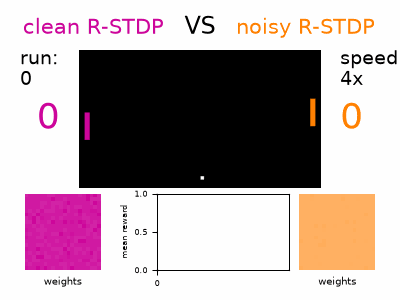

In [11]:
from IPython.display import Image, display

display(Image(filename=renderer.get_output("gif_path")))